In [157]:
import pandas as pd
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

## Load in data

In [158]:
# read data from travelling_salesman.csv
data = pd.read_csv("travelling_salesperson.csv")
data.head() # display the first few rows of the dataset

,ID,Years in Business,Total Sales,Region,Gender,Avg Discount,Customer Satisfaction,Training Hours
0,1,2,200000,North,Male,NaN,3.5,400
1,2,5,550000,NaN,Female,NaN,4.0,50
2,3,10,980000,West,Male,14.3,NaN,10
3,4,1,80000,North,Female,NaN,5.0,100
4,5,15,1600000,North,Male,NaN,4.5,10


In [159]:
# remove the "ID" column since it is not useful for our analysis
data = data.drop(columns=["ID"])
data.head()

,Years in Business,Total Sales,Region,Gender,Avg Discount,Customer Satisfaction,Training Hours
0,2,200000,North,Male,NaN,3.5,400
1,5,550000,NaN,Female,NaN,4.0,50
2,10,980000,West,Male,14.3,NaN,10
3,1,80000,North,Female,NaN,5.0,100
4,15,1600000,North,Male,NaN,4.5,10


## Missing data

In [160]:
# check for missing values in the dataset
data.isnull().sum()

Years in Business        0
Total Sales              0
Region                   1
Gender                   0
Avg Discount             5
Customer Satisfaction    1
Training Hours           0
dtype: int64

In [161]:
# compute the percentage of missing values in each column
missing_percent = data.isnull().mean() * 100
print(missing_percent)

Years in Business         0.000000
Total Sales               0.000000
Region                   14.285714
Gender                    0.000000
Avg Discount             71.428571
Customer Satisfaction    14.285714
Training Hours            0.000000
dtype: float64


In [162]:
# drop column "Avg Discount (%)" since it has a high percentage of missing values
data = data.drop(columns=["Avg Discount"])
# check again for missing values
data.isnull().sum()

Years in Business        0
Total Sales              0
Region                   1
Gender                   0
Customer Satisfaction    1
Training Hours           0
dtype: int64

In [163]:
# impute the missing value in Region with mode
most_frequent_region = data["Region"].mode()[0]
data["Region"] = data["Region"].fillna(most_frequent_region)
data.head()

,Years in Business,Total Sales,Region,Gender,Customer Satisfaction,Training Hours
0,2,200000,North,Male,3.5,400
1,5,550000,North,Female,4.0,50
2,10,980000,West,Male,NaN,10
3,1,80000,North,Female,5.0,100
4,15,1600000,North,Male,4.5,10


In [164]:
# impute the missing value in Customer Satisfaction using knn imputation
imputer = KNNImputer(n_neighbors=5)
data_imputed = imputer.fit_transform(data[["Customer Satisfaction"]])
data["Customer Satisfaction"] = data_imputed
data.head()

,Years in Business,Total Sales,Region,Gender,Customer Satisfaction,Training Hours
0,2,200000,North,Male,3.50,400
1,5,550000,North,Female,4.00,50
2,10,980000,West,Male,3.95,10
3,1,80000,North,Female,5.00,100
4,15,1600000,North,Male,4.50,10


In [165]:
data.isnull().sum()

Years in Business        0
Total Sales              0
Region                   0
Gender                   0
Customer Satisfaction    0
Training Hours           0
dtype: int64

## Outliers

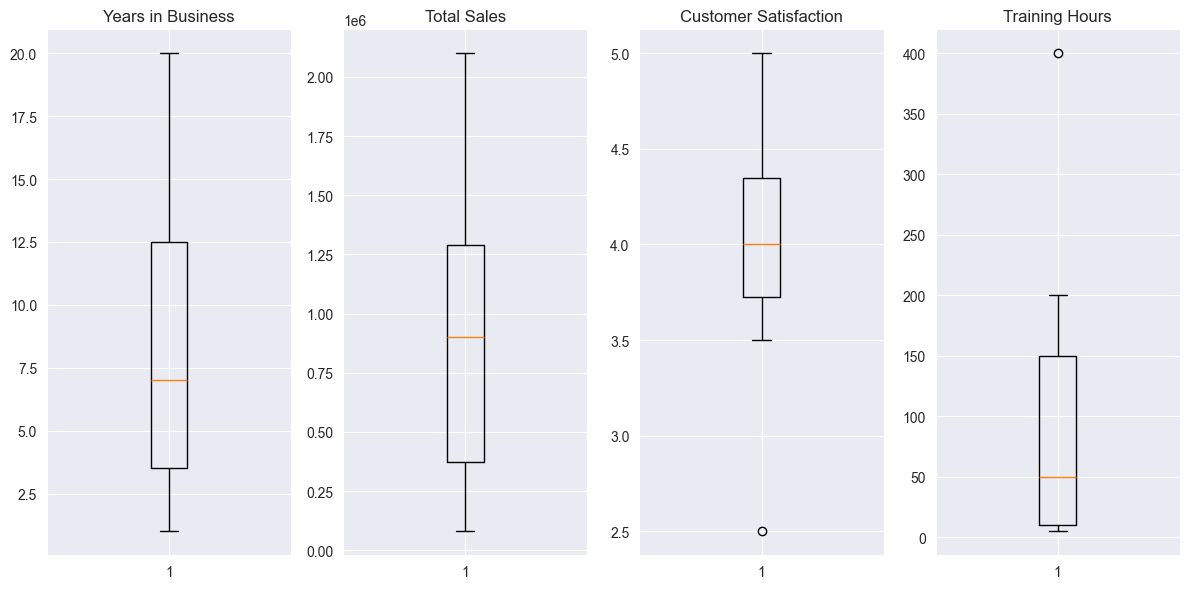

In [166]:
# box plot of Years in Business, Total Sales, Customer Satisfaction and Training Hours
plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.boxplot(data["Years in Business"])
plt.title("Years in Business")

plt.subplot(1, 4, 2)
plt.boxplot(data["Total Sales"])
plt.title("Total Sales")

plt.subplot(1, 4, 3)
plt.boxplot(data["Customer Satisfaction"])
plt.title("Customer Satisfaction")

plt.subplot(1, 4, 4)
plt.boxplot(data["Training Hours"])
plt.title("Training Hours")

plt.tight_layout()
plt.show()

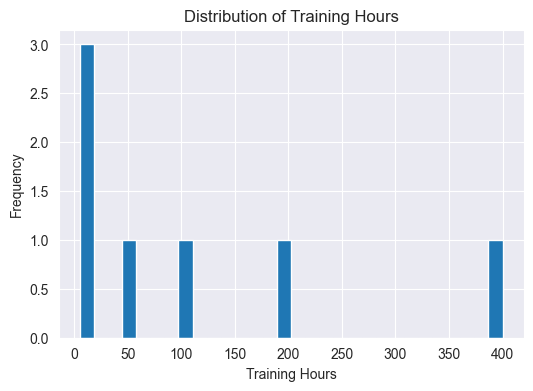

In [167]:
# plot skewness of Training Hours
plt.figure(figsize=(6, 4))
plt.hist(data["Training Hours"], bins=30)
plt.title("Distribution of Training Hours")
plt.xlabel("Training Hours")
plt.ylabel("Frequency")
plt.show()

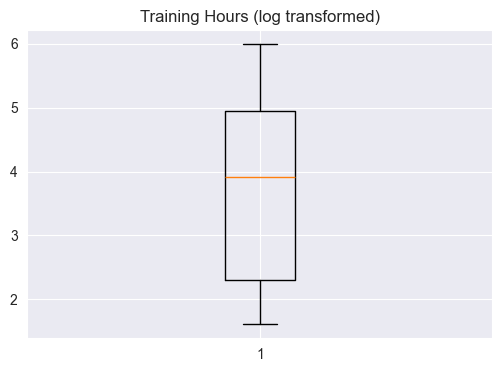

In [168]:
# transform Training hours using log transformation to reduce the effect of outliers
data["Training Hours"] = data["Training Hours"].apply(lambda x: np.log(x))
# box plot of Training Hours after log transformation
plt.figure(figsize=(6, 4))
plt.boxplot(data["Training Hours"])
plt.title("Training Hours (log transformed)")
plt.show()

In [169]:
data.head()

,Years in Business,Total Sales,Region,Gender,Customer Satisfaction,Training Hours
0,2,200000,North,Male,3.50,5.991465
1,5,550000,North,Female,4.00,3.912023
2,10,980000,West,Male,3.95,2.302585
3,1,80000,North,Female,5.00,4.605170
4,15,1600000,North,Male,4.50,2.302585


## One-hot encoding

In [170]:
# one-hot encoding for Region column
data = pd.get_dummies(data, columns=["Region"])
data.head()

,Years in Business,Total Sales,Gender,Customer Satisfaction,Training Hours,Region_East,Region_North,Region_South,Region_West
0,2,200000,Male,3.50,5.991465,False,True,False,False
1,5,550000,Female,4.00,3.912023,False,True,False,False
2,10,980000,Male,3.95,2.302585,False,False,False,True
3,1,80000,Female,5.00,4.605170,False,True,False,False
4,15,1600000,Male,4.50,2.302585,False,True,False,False


In [171]:
# one-hot encoding for Gender column
data = pd.get_dummies(data, columns=["Gender"], drop_first=True) # drop_first=True to avoid the last category being redundant
data.head()

,Years in Business,Total Sales,Customer Satisfaction,Training Hours,Region_East,Region_North,Region_South,Region_West,Gender_Male
0,2,200000,3.50,5.991465,False,True,False,False,True
1,5,550000,4.00,3.912023,False,True,False,False,False
2,10,980000,3.95,2.302585,False,False,False,True,True
3,1,80000,5.00,4.605170,False,True,False,False,False
4,15,1600000,4.50,2.302585,False,True,False,False,True


## Bag of words

In [172]:
# dummy data
sentences = ["The green frog jumps over the small frog.", "A quick lizard runs past the green lizard."]
# remove punctuation and convert to lowercase
sentences = [s.lower().replace(".", "") for s in sentences]

In [173]:
# using CountVectorizer to create a bag of words representation
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(sentences)
# convert the sparse matrix to a dense array and then to a DataFrame for better visualization
bow_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
bow_df

,frog,green,jumps,lizard,over,past,quick,runs,small,the
0,2,1,1,0,1,0,0,0,1,2
1,0,1,0,2,0,1,1,1,0,1


## Correlation matrix

In [174]:
# compute covariance and correlation between Years in Business and Total Sales
covariance = np.cov(data["Years in Business"], data["Total Sales"])[0, 1]
correlation = np.corrcoef(data["Years in Business"], data["Total Sales"])[0, 1]
print(f"Covariance: {covariance}")
print(f"Correlation: {correlation}")

Covariance: 5064523.80952381
Correlation: 0.9949605924375763


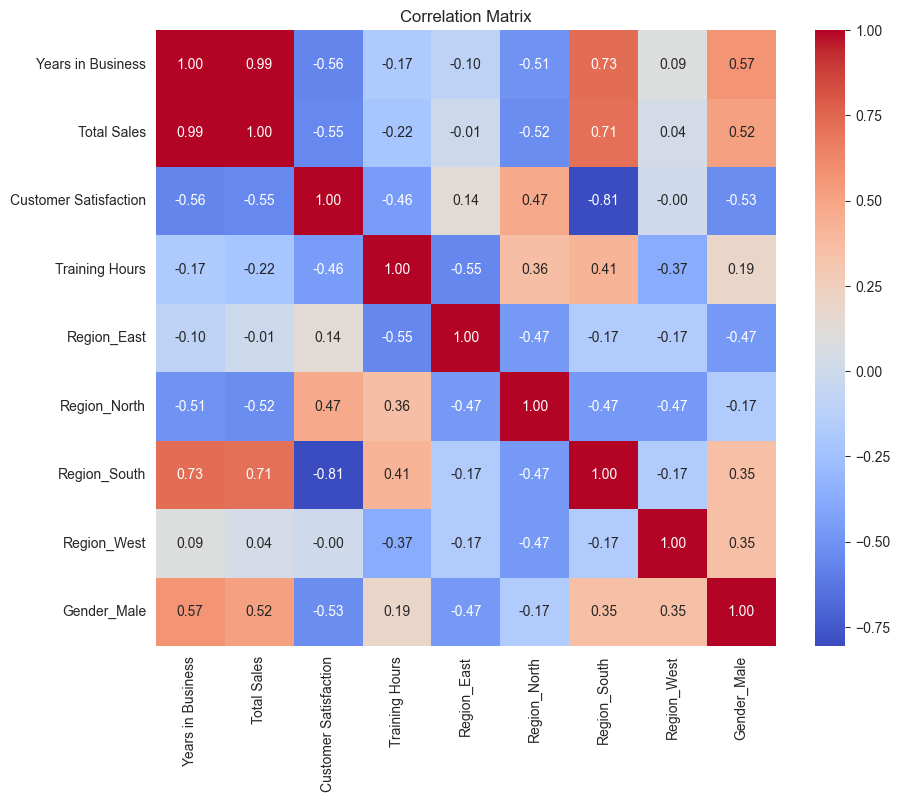

In [175]:
# correlation matrix with seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

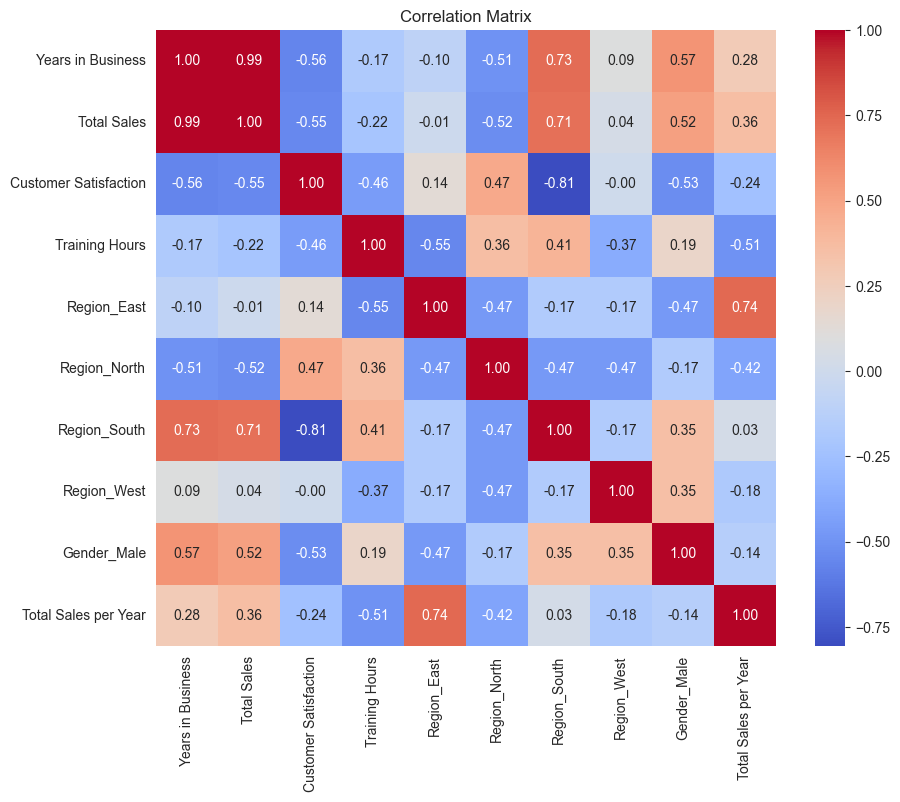

In [176]:
# create a new column "Total Sales per Years" by dividing Total Sales by Years in Business
data["Total Sales per Year"] = data["Total Sales"] / data["Years in Business"]

plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

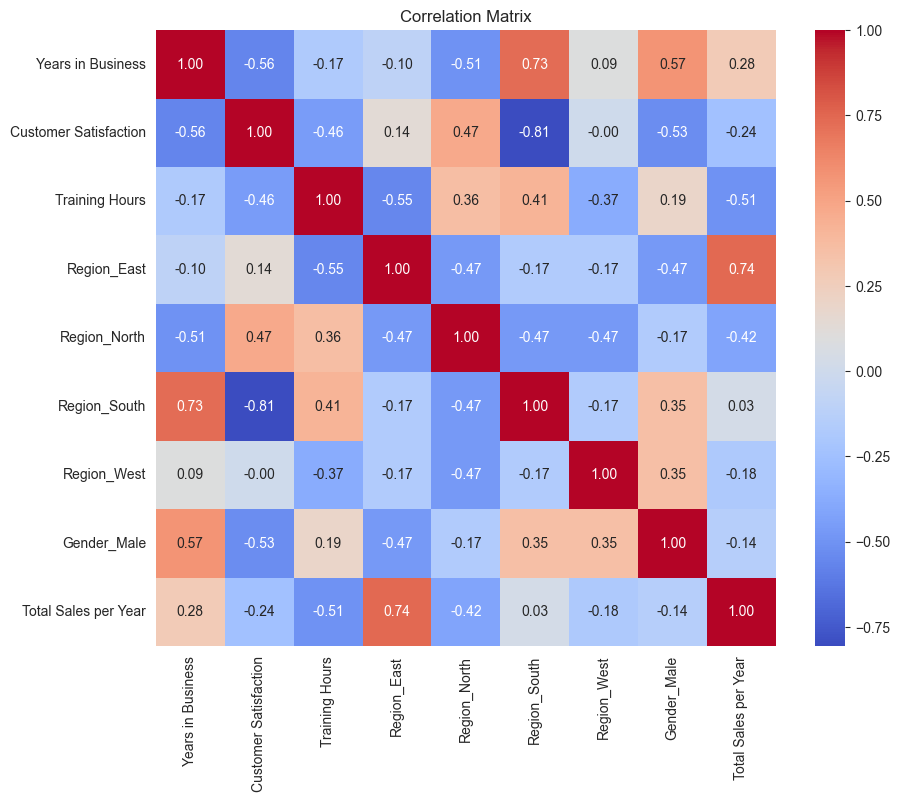

In [177]:
# drop Total Sales
data = data.drop(columns=["Total Sales"])
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Scaling

In [178]:
# scale Years In Business, Total Sales, Customer Satisfaction and Training Hours using standard scaler
scaler = StandardScaler()
data[["Years in Business", "Total Sales per Year", "Customer Satisfaction", "Training Hours"]] = scaler.fit_transform(
    data[["Years in Business", "Total Sales per Year", "Customer Satisfaction", "Training Hours"]]
)
data.head()

,Years in Business,Customer Satisfaction,Training Hours,Region_East,Region_North,Region_South,Region_West,Gender_Male,Total Sales per Year
0,-1.021466,-0.612778,1.461689,False,True,False,False,True,-0.298803
1,-0.555144,0.068086,0.125115,False,True,False,False,False,0.441906
2,0.222058,0.000000,-0.909361,False,False,False,True,True,-0.446945
3,-1.176906,1.429815,0.570640,False,True,False,False,False,-1.780222
4,0.999260,0.748951,-0.909361,False,True,False,False,True,0.195003


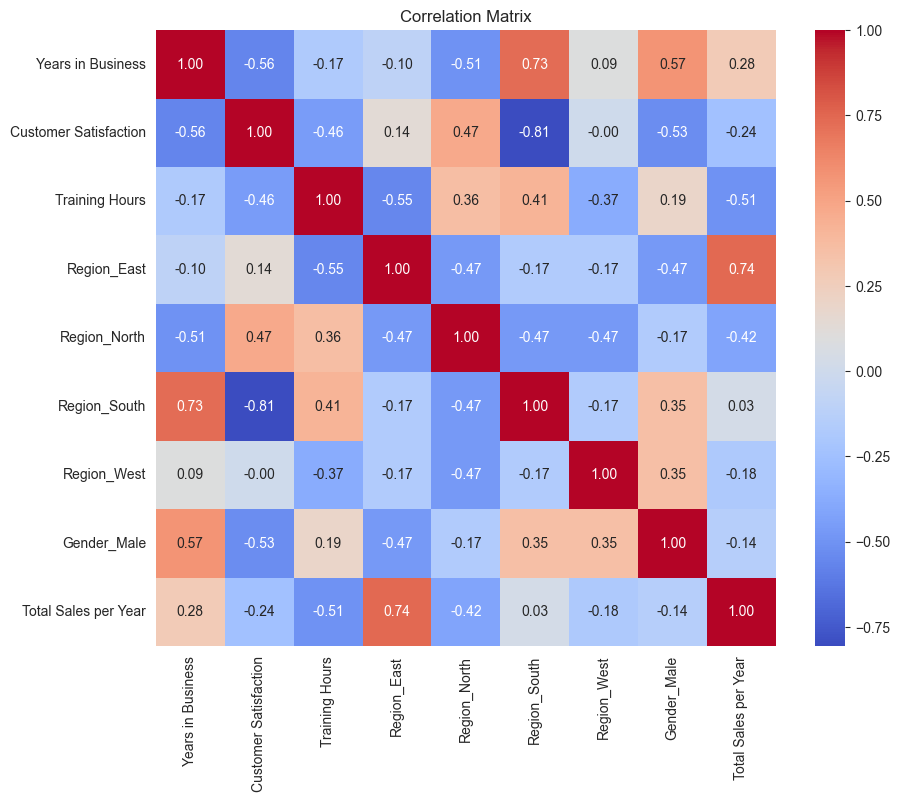

In [179]:
# the correlation matrix after scaling will be the same as before scaling since correlation is scale-invariant
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [180]:
data.head()

,Years in Business,Customer Satisfaction,Training Hours,Region_East,Region_North,Region_South,Region_West,Gender_Male,Total Sales per Year
0,-1.021466,-0.612778,1.461689,False,True,False,False,True,-0.298803
1,-0.555144,0.068086,0.125115,False,True,False,False,False,0.441906
2,0.222058,0.000000,-0.909361,False,False,False,True,True,-0.446945
3,-1.176906,1.429815,0.570640,False,True,False,False,False,-1.780222
4,0.999260,0.748951,-0.909361,False,True,False,False,True,0.195003
